# Data Inspection

**Dataset:** [Accidents in France from 2005 to 2016](https://www.kaggle.com/ahmedlahlou/accidents-in-france-from-2005-to-2016) (French BAAC police accident reports)

This notebook inspects/explores the French BAAC national accident records, what each file contains, how clean the data is, how the key variables are distributed and relate to each other, and the exploratory cuts that originated the  insight ideas developed in `02_insight_charts.ipynb`.

| File | Grain | Content |
|---|---|---|
| `caracteristics.csv` | 1 row per accident | date, time, lighting, location type, weather, collision type |
| `places.csv` | 1 row per accident | road category, lanes, surface, curvature, infrastructure |
| `users.csv` | 1 row per involved person | severity (`grav`), role (`catu`), age, sex, safety equipment |
| `vehicles.csv` | 1 row per vehicle | vehicle category, obstacle hit, pre crash maneuver |
| `holidays.csv` | 1 row per holiday | French public holidays 2005 to 2016 |


## 1. Setup

In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

GREEN, LGREEN, GRAY, MUTED = "#046A38", "#86BC25", "#a7a8aa", "#97999B"
sns.set_theme(style="whitegrid", palette=[GREEN, LGREEN, GRAY])
plt.rcParams["figure.dpi"] = 100

# Download the dataset from Kaggle
path = kagglehub.dataset_download("ahmedlahlou/accidents-in-france-from-2005-to-2016")
print("data at:", path)

C:\Users\User\Documents\vibe\delo\france_accidents\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


data at: C:\Users\User\.cache\kagglehub\datasets\ahmedlahlou\accidents-in-france-from-2005-to-2016\versions\2


In [2]:
car = pd.read_csv(f"{path}/caracteristics.csv", encoding="latin-1", low_memory=False)
plc = pd.read_csv(f"{path}/places.csv", encoding="latin-1", low_memory=False)
usr = pd.read_csv(f"{path}/users.csv", encoding="latin-1", low_memory=False)
veh = pd.read_csv(f"{path}/vehicles.csv", encoding="latin-1", low_memory=False)
hol = pd.read_csv(f"{path}/holidays.csv", encoding="latin-1")
files = {"caracteristics": car, "places": plc, "users": usr, "vehicles": veh, "holidays": hol}

## 2. Files

In [3]:
for name, df in files.items():
    print(f"{name:16s} {df.shape[0]:>9,} rows x {df.shape[1]:>2} cols | columns: {list(df.columns)}")

caracteristics     839,985 rows x 16 cols | columns: ['Num_Acc', 'an', 'mois', 'jour', 'hrmn', 'lum', 'agg', 'int', 'atm', 'col', 'com', 'adr', 'gps', 'lat', 'long', 'dep']
places             839,985 rows x 18 cols | columns: ['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'pr', 'pr1', 'vosp', 'prof', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'env1']
users            1,876,005 rows x 12 cols | columns: ['Num_Acc', 'place', 'catu', 'grav', 'sexe', 'trajet', 'secu', 'locp', 'actp', 'etatp', 'an_nais', 'num_veh']
vehicles         1,433,389 rows x  9 cols | columns: ['Num_Acc', 'senc', 'catv', 'occutc', 'obs', 'obsm', 'choc', 'manv', 'num_veh']
holidays               132 rows x  2 cols | columns: ['ds', 'holiday']


In [4]:
car.head(3)

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,com,adr,gps,lat,long,dep
0,201600000001,16,2,1,1445,1,2,1,8.0,3.0,5.0,"46, rue Sonneville",M,0.0,0,590
1,201600000002,16,3,16,1800,1,2,6,1.0,6.0,5.0,1a rue du cimetière,M,0.0,0,590
2,201600000003,16,7,13,1900,1,1,1,1.0,6.0,11.0,NaN,M,0.0,0,590


In [5]:
usr.head(3)

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh
0,201600000001,1.0,1,1,2,0.0,11.0,0.0,0.0,0.0,1983.0,B02
1,201600000001,1.0,1,3,1,9.0,21.0,0.0,0.0,0.0,2001.0,A01
2,201600000002,1.0,1,3,1,5.0,11.0,0.0,0.0,0.0,1960.0,A01


Key coded fields (BAAC dictionary):

- `caracteristics`: `an/mois/jour/hrmn` date and time, `lum` lighting (1 day ... 5 night lit),
  `agg` location (1 outside built up, 2 inside), `atm` weather, `col` collision type, `dep` département.
- `places`: `catr` road category (1 motorway, 2 national, 3 départemental, 4 communal), `nbv` lanes,
  `plan` curvature (1 straight, 2 to 4 curves), `surf` surface condition.
- `users`: `grav` severity, `catu` role (1 driver, 2 passenger, 3 pedestrian), `sexe`, `an_nais`
  birth year, `trajet` trip purpose, `secu` safety equipment, `locp` pedestrian location.
- `vehicles`: `catv` vehicle category, `obs/obsm` obstacle hit, `manv` pre crash maneuver.

## 3. Quality

In [6]:
# missing values per file (columns with any NaN)
for name, df in files.items():
    miss = df.isna().mean().mul(100).round(1)
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"--- {name}, columns with missing values (%) ---")
    print(miss.to_string() if len(miss) else "  none")

--- caracteristics, columns with missing values (%) ---
long    56.8
lat     56.8
gps     56.4
adr     16.7
--- places, columns with missing values (%) ---
v2         96.0
v1         60.4
pr1        50.8
pr         50.6
voie        7.0
lartpc      1.1
larrout     1.0
nbv         0.2
env1        0.2
vosp        0.2
infra       0.2
circ        0.1
prof        0.1
plan        0.1
surf        0.1
situ        0.1


--- users, columns with missing values (%) ---
place      5.3
secu       2.3
locp       0.1
actp       0.1
etatp      0.1
an_nais    0.1
--- vehicles, columns with missing values (%) ---
obs    0.1
--- holidays, columns with missing values (%) ---
  none


In [ ]:
# date validity and derived fields used everywhere below
usr["killed"] = (usr.grav == 2).astype(int)
car["year"] = 2000 + car.an
car["hour"] = (car.hrmn // 100).clip(0, 23)
car["date"] = pd.to_datetime(dict(year=car.year, month=car.mois, day=car.jour), errors="coerce")
car["dow"] = car.date.dt.dayofweek

print(f"unparseable dates: {car.date.isna().sum()} of {len(car):,}")
u = usr.merge(car[["Num_Acc", "year", "hour", "dow", "date", "agg", "lum", "mois"]], on="Num_Acc")
u["age"] = u.year - u.an_nais

print(f"{len(car):,} accidents | {len(usr):,} involved persons | {usr.killed.sum():,} deaths")

unparseable dates: 0 of 839,985


839,985 accidents | 1,876,005 involved persons | 50,589 deaths


In [ ]:
# caution, the vehicle category coding changed in 2006, 2005 is not comparable
uv = u.merge(veh[["Num_Acc", "num_veh", "catv", "manv"]], on=["Num_Acc", "num_veh"], how="left")
uv["uclass"] = np.select(
    [uv.catu.eq(3), uv.catv.eq(1), uv.catv.isin([2, 30, 31, 32, 33, 34]), uv.catv.eq(7)],
    ["Pedestrians", "Cyclists", "Motorized 2W", "Car occupants"], default="other")
d = uv[uv.killed == 1].groupby(["year", "uclass"]).size().unstack()

print(d.head(4).to_string())
print("-> Motorized 2W jumps 394 (2005) to 1,028 (2006), a coding change, not reality.")
print("-> Consequence, any trend by vehicle class must start in 2006.")

uclass  Car occupants  Cyclists  Motorized 2W  Pedestrians  other
year                                                             
2005             3159       187           394          676   1127
2006             2728       190          1028          569    427
2007             2544       156          1224          584    330
2008             2257       159          1158          577    292
-> Motorized 2W jumps 394 (2005) to 1,028 (2006), a coding change, not reality.
-> Consequence, any trend by vehicle class must start in 2006.


Quality notes carried into the analysis:

1. **Missing values are rare in the fields we use**; most gaps are in free text or secondary fields.
2. **Zero often means unknown** in coded fields (`manv` 0, `secu` third digit, `atm` 0), so category
   tables keep an explicit unknown bucket rather than dropping rows.
3. **`catv` recoding in 2006** makes 2005 incompatible for vehicle class trends, trends are indexed
   to 2006.
4. Dates parse cleanly, hours are stored as `hhmm` integers and need `// 100`.

## 4. Distributions

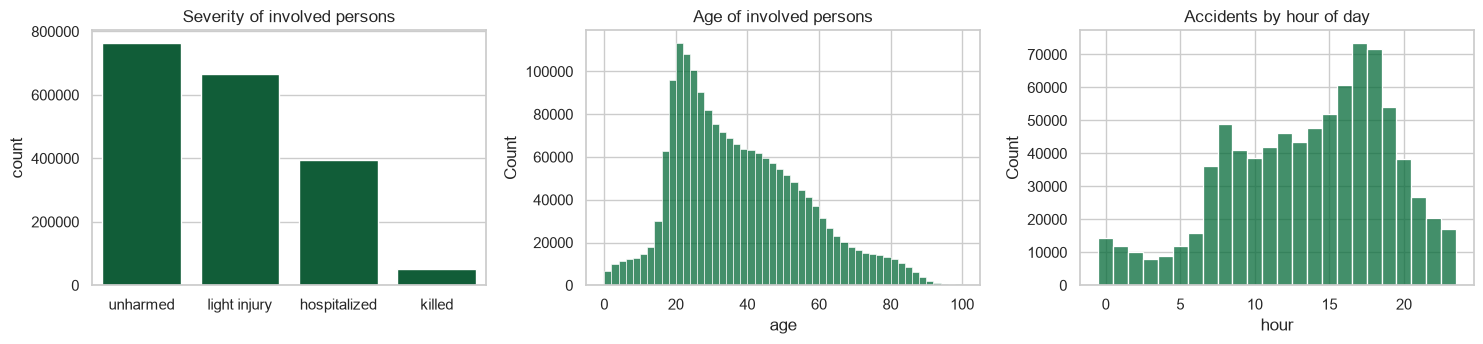

overall death rate 2.70%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
sev = usr.grav.map({1: "unharmed", 2: "killed", 3: "hospitalized", 4: "light injury"})

sns.countplot(x=sev, order=["unharmed", "light injury", "hospitalized", "killed"],
              color=GREEN, ax=axes[0])
axes[0].set_title("Severity of involved persons")
axes[0].set_xlabel("")
sns.histplot(u.age.dropna().clip(0, 100), bins=50, color=GREEN, ax=axes[1])
axes[1].set_title("Age of involved persons")
sns.histplot(car.hour, bins=24, discrete=True, color=GREEN, ax=axes[2])
axes[2].set_title("Accidents by hour of day")
plt.tight_layout()
plt.show()

print(f"overall death rate {100 * usr.killed.mean():.2f}%")

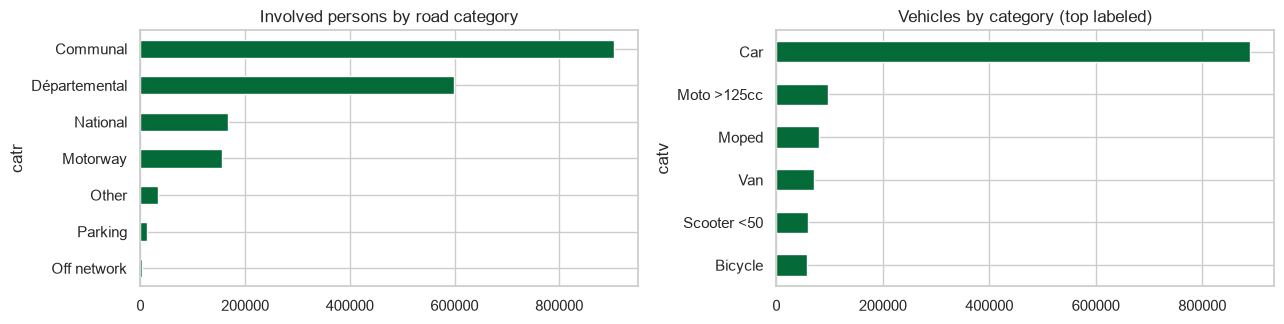

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
rc = usr.merge(plc[["Num_Acc", "catr"]], on="Num_Acc").groupby("catr").size()
rc.index = rc.index.map({1: "Motorway", 2: "National", 3: "Départemental", 4: "Communal",
                         5: "Off network", 6: "Parking", 9: "Other"})
rc.sort_values().plot.barh(color=GREEN, ax=axes[0])
axes[0].set_title("Involved persons by road category")
cat_lab = {7: "Car", 33: "Moto >125cc", 2: "Moped", 30: "Scooter <50", 10: "Van", 1: "Bicycle"}
vc = veh.catv.map(cat_lab).value_counts()
vc.sort_values().plot.barh(color=GREEN, ax=axes[1])
axes[1].set_title("Vehicles by category (top labeled)")
plt.tight_layout()
plt.show()

## 5. Relationships

Before slicing, two quick screens. First a correlation heatmap of engineered risk flags against
`killed`. Individually every flag correlates only weakly, fatal outcomes are rare and conditional,
which is exactly why the analysis proceeds by cuts (death rate inside a condition) rather than by
raw correlation.

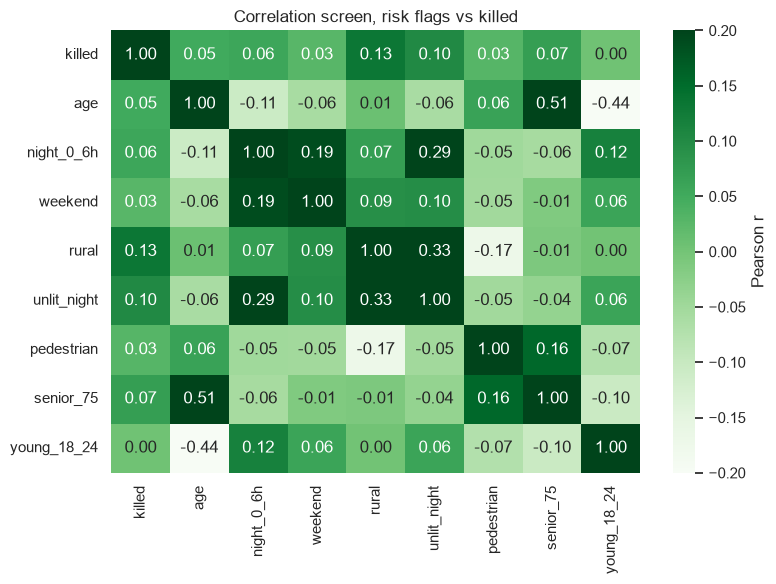

In [11]:
flags = pd.DataFrame({
    "killed": u.killed,
    "age": u.age.clip(0, 100),
    "night_0_6h": u.hour.between(0, 6).astype(int),
    "weekend": u.dow.isin([5, 6]).astype(int),
    "rural": u["agg"].eq(1).astype(int),
    "unlit_night": u.lum.eq(3).astype(int),
    "pedestrian": u.catu.eq(3).astype(int),
    "senior_75": u.age.ge(75).astype(int),
    "young_18_24": u.age.between(18, 24).astype(int),
})
plt.figure(figsize=(8, 6))
sns.heatmap(flags.corr(), annot=True, fmt=".2f", cmap="Greens", vmin=-0.2, vmax=0.2,
            cbar_kws={"label": "Pearson r"})
plt.title("Correlation screen, risk flags vs killed")
plt.tight_layout()
plt.show()

`rural` (r ≈ 0.10) and `unlit_night` are the strongest single correlates of death, everything
else is diluted by the 97% of rows that are non fatal. Second screen, aggregate scatterplots.
If risk were proportional to traffic, more crashes would mean more deaths per crash. The opposite
appears at every aggregation level, months, day types and départements with FEWER crashes have
HIGHER death rates.

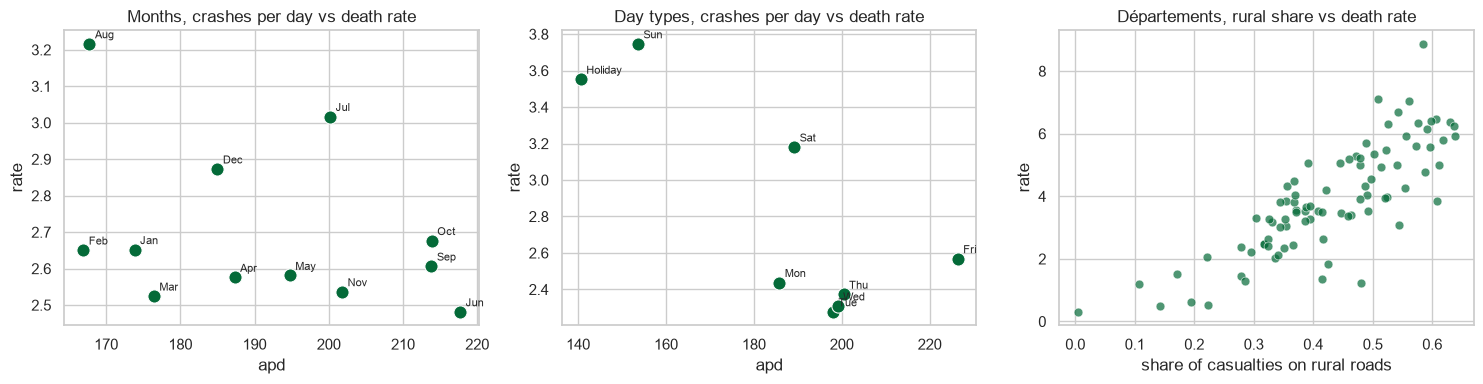

département level correlation, rural share vs death rate, r = 0.82


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

m = u.groupby("mois").agg(persons=("killed", "size"), killed=("killed", "sum"))
m["rate"] = 100 * m.killed / m.persons
days_pm = {1: 31, 2: 28.25, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}
m["apd"] = [car.groupby("mois").size()[i] / (days_pm[i] * 12) for i in m.index]
sns.scatterplot(data=m, x="apd", y="rate", s=90, color=GREEN, ax=axes[0])
for i, r in m.iterrows():
    axes[0].annotate(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][i-1],
                     (r.apd, r.rate), textcoords="offset points", xytext=(4, 4), fontsize=8)
axes[0].set_title("Months, crashes per day vs death rate")

hol_dates = set(pd.to_datetime(hol.ds).dt.date)
u["day"] = u.date.dt.date
u["cat"] = u.dow.map({0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"})
u.loc[u.day.isin(hol_dates), "cat"] = "Holiday"
cd = car.dropna(subset=["date"]).copy()
cd["day"] = cd.date.dt.date
cd["cat"] = cd.dow.map({0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"})
cd.loc[cd.day.isin(hol_dates), "cat"] = "Holiday"
dt = u.groupby("cat").killed.mean().mul(100).rename("rate").to_frame()
dt["apd"] = cd.groupby("cat").size() / cd.groupby("cat").day.nunique()

sns.scatterplot(data=dt, x="apd", y="rate", s=90, color=GREEN, ax=axes[1])
for name, r in dt.iterrows():
    axes[1].annotate(name, (r.apd, r.rate), textcoords="offset points", xytext=(4, 4), fontsize=8)
axes[1].set_title("Day types, crashes per day vs death rate")

dep = u.merge(car[["Num_Acc", "dep"]], on="Num_Acc")
g = dep.groupby("dep").agg(persons=("killed", "size"), killed=("killed", "sum"),
                           rural=("agg", lambda s: (s == 1).mean()))
g = g[g.persons > 5000]
g["rate"] = 100 * g.killed / g.persons
sns.scatterplot(data=g, x="rural", y="rate", s=40, color=GREEN, alpha=0.7, ax=axes[2])
axes[2].set_title("Départements, rural share vs death rate")
axes[2].set_xlabel("share of casualties on rural roads")
plt.tight_layout()
plt.show()

print(f"département level correlation, rural share vs death rate, r = {g.rural.corr(g.rate):.2f}")

All three panels tell the same story, **quiet means deadly**, quiet months (August), quiet
days (Sundays, holidays), and rural départements all sit high on death rate and low on volume.
That meta pattern drives the WHEN and WHERE cuts below.

## 6. Exploration

Each cut below ends with the insight idea it produced, the ideas become the six charts of
`02_insight_charts.ipynb`.

### 6.1. Timing

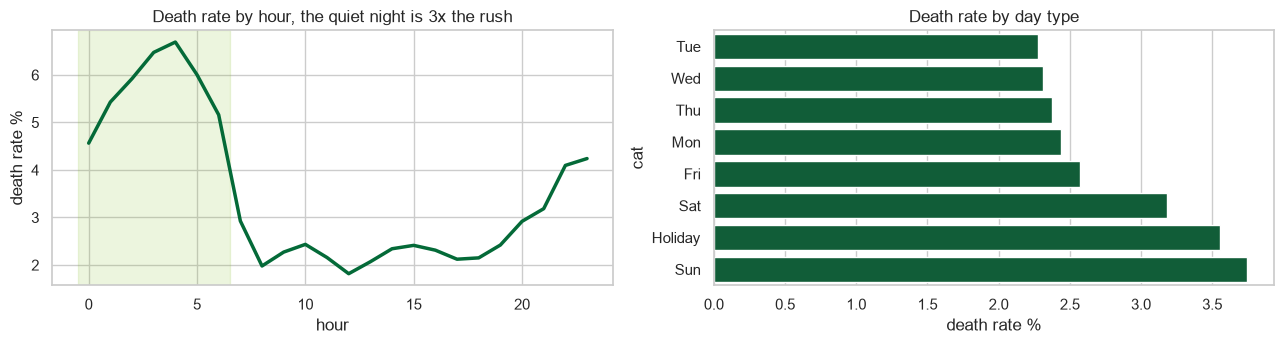

In [ ]:
t = u.groupby("hour").agg(persons=("killed", "size"), killed=("killed", "sum"))
t["rate"] = 100 * t.killed / t.persons

# viz
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(t.index, t.rate, color=GREEN, lw=2.5)
axes[0].axvspan(-0.5, 6.5, color=LGREEN, alpha=0.15)
axes[0].set_title("Death rate by hour, the quiet night is 3x the rush")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("death rate %")
dt_rates = u.groupby("cat").killed.mean().mul(100).sort_values()
sns.barplot(x=dt_rates.values, y=dt_rates.index, color=GREEN, ax=axes[1])
axes[1].set_title("Death rate by day type")
axes[1].set_xlabel("death rate %")
plt.tight_layout()
plt.show()

**Insight idea (WHEN)**, crashes cluster at rush hour but deaths per crash peak in the small hours (6.7% at 4am) and on Sundays and holidays, the road kills most when it is quiet.

### 6.2. Young

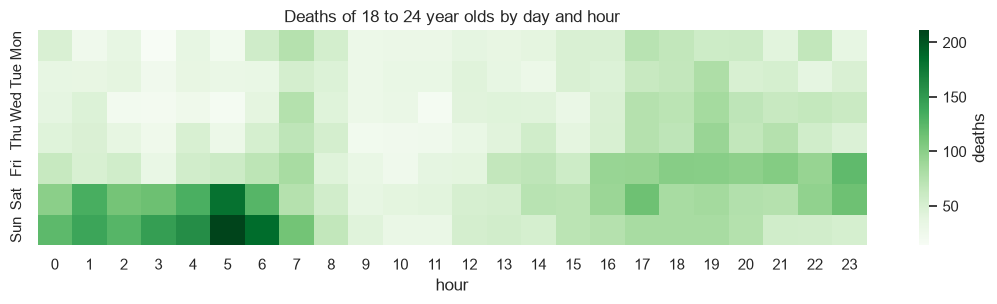

share of deaths on weekend nights, 18 to 24: 24.5% | 30 to 60: 13.6%


In [ ]:
young_k = u[(u.age >= 18) & (u.age <= 24) & (u.killed == 1)]
hm = young_k.groupby(["dow", "hour"]).size().unstack(fill_value=0)

# viz
plt.figure(figsize=(11, 3.2))
sns.heatmap(hm, cmap="Greens", cbar_kws={"label": "deaths"},
            yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("Deaths of 18 to 24 year olds by day and hour")
plt.xlabel("hour")
plt.ylabel("")
plt.tight_layout()
plt.show()
older = u[(u.age >= 30) & (u.age <= 60) & (u.killed == 1)]
wn = lambda g: 100 * ((g.dow.isin([4, 5, 6])) & ((g.hour >= 22) | (g.hour < 6))).mean()

print(f"share of deaths on weekend nights, 18 to 24: {wn(young_k):.1f}% | 30 to 60: {wn(older):.1f}%")

**Insight idea (WHO, young)**, one in four deaths of 18 to 24 year olds happens on a weekend night, peaking Saturday and Sunday 4am to 6am, the ride home from a night out.

### 6.3. Ages

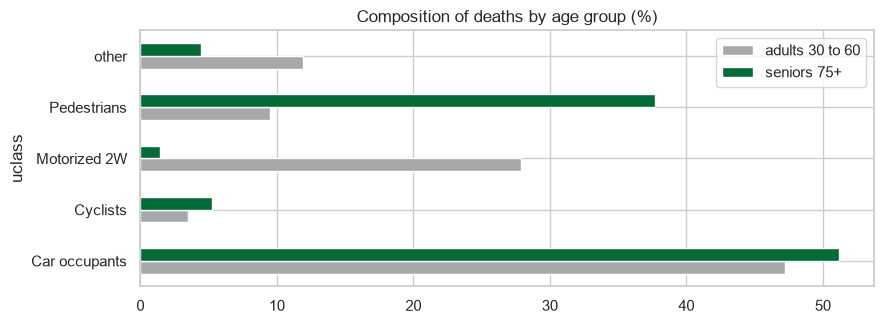

senior pedestrian deaths near a crossing (locp 2 to 4): 66%


In [ ]:
mid_k = uv[(uv.age >= 30) & (uv.age <= 60) & (uv.killed == 1)]
old_k = uv[(uv.age >= 75) & (uv.killed == 1)]
comp = pd.DataFrame({
    "adults 30 to 60": mid_k.uclass.value_counts(normalize=True).mul(100),
    "seniors 75+": old_k.uclass.value_counts(normalize=True).mul(100),
})

comp.plot.barh(figsize=(9, 3.4), color=[GRAY, GREEN])
plt.title("Composition of deaths by age group (%)")
plt.tight_layout()
plt.show()

ped_old = u[(u.age >= 75) & (u.killed == 1) & (u.catu == 3)]
print(f"senior pedestrian deaths near a crossing (locp 2 to 4): "
      f"{100 * usr.loc[ped_old.index, 'locp'].isin([2, 3, 4]).mean():.0f}%")

**Insight idea (WHO, senior)**, the pedestrian share of deaths is 4x higher for seniors (38% vs 9%), and two thirds of those die at or near a pedestrian crossing.

### 6.4. Trends

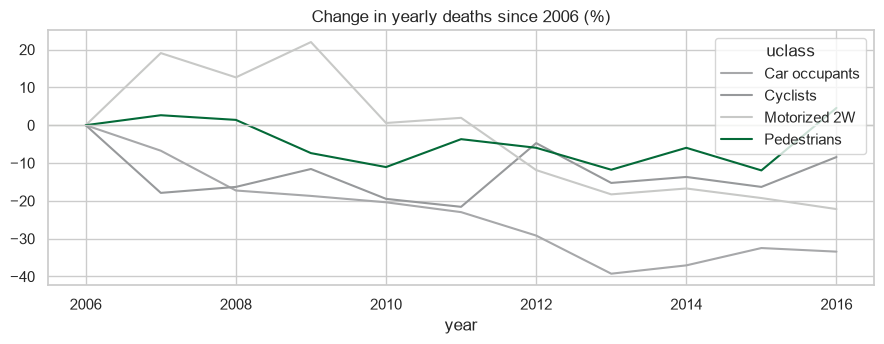

uclass
Car occupants   -33.0
Cyclists         -8.0
Motorized 2W    -22.0
Pedestrians       5.0


In [ ]:
d06 = d[d.index >= 2006].drop(columns="other")
chg = 100 * d06 / d06.iloc[0] - 100
chg.plot(figsize=(9, 3.6), color=[GRAY, MUTED, "#c8c9c7", GREEN])

plt.axhline(0, color="#c8c9c7", lw=1)
plt.title("Change in yearly deaths since 2006 (%)")
plt.tight_layout()
plt.show()

print(chg.iloc[-1].round(0).to_string())

**Insight idea (WHAT)**, since 2006 deaths dropped for every class except pedestrians (+5%), the only group whose deaths are growing.

### 6.5. Roads

In [ ]:
rr = usr.merge(plc[["Num_Acc", "catr", "nbv", "plan"]], on="Num_Acc")
t = rr.groupby("catr").agg(persons=("killed", "size"), killed=("killed", "sum"))
t["rate_%"] = (100 * t.killed / t.persons).round(2)
t["share_of_deaths_%"] = (100 * t.killed / t.killed.sum()).round(1)
t.index = t.index.map({1: "Motorway", 2: "National", 3: "Départemental", 4: "Communal",
                       5: "Off network", 6: "Parking", 9: "Other"})

print(t.sort_values("share_of_deaths_%", ascending=False).to_string())

two = rr[rr.nbv.eq(2)].killed.mean() * 100
four = rr[rr.nbv.eq(4)].killed.mean() * 100
curve = rr[rr.plan.isin([2, 3, 4])].killed.mean() * 100
straight = rr[rr.plan.eq(1)].killed.mean() * 100

print(f"two lanes {two:.1f}% vs four lanes {four:.1f}% | curves {curve:.1f}% vs straight {straight:.1f}%")

               persons  killed  rate_%  share_of_deaths_%
catr                                                     
Départemental   598716   31027    5.18               61.3
Communal        905247    8575    0.95               17.0
National        167530    6824    4.07               13.5
Motorway        156237    3372    2.16                6.7
Other            33381     552    1.65                1.1
Parking          11689     144    1.23                0.3
Off network       3203      95    2.97                0.2


two lanes 3.2% vs four lanes 1.4% | curves 5.4% vs straight 2.3%


**Insight idea (WHERE)**, départemental roads carry 61% of all deaths, mostly undivided two lane roads where curves double the risk.

### 6.6. Maneuvers

In [ ]:
occ = uv[uv.catu.isin([1, 2])]
total_deaths = usr.killed.sum()
manv_lab = {0: "unknown", 1: "no direction change", 13: "drifted left", 14: "drifted right",
            15: "turning left", 16: "turning right", 17: "overtaking left", 18: "overtaking right"}
t = occ.groupby("manv").agg(persons=("killed", "size"), killed=("killed", "sum"))

t["rate_%"] = (100 * t.killed / t.persons).round(2)
t["share_of_all_deaths_%"] = (100 * t.killed / total_deaths).round(1)
t.index = t.index.map(lambda k: manv_lab.get(k, f"code {int(k)}"))
top = t.sort_values("share_of_all_deaths_%", ascending=False).head(8)
print(top.to_string())

                     persons  killed  rate_%  share_of_all_deaths_%
manv                                                               
no direction change   778037   20446    2.63                   40.4
drifted left           77247    8022   10.38                   15.9
unknown               131076    2847    2.17                    5.6
drifted right          31391    2294    7.31                    4.5
overtaking left        57763    2131    3.69                    4.2
code 2                194989    1939    0.99                    3.8
code 19                34010    1571    4.62                    3.1
turning left          144203    1143    0.79                    2.3


**Insight idea (HOW and WHY)**, drifting out of the lane precedes 20% of all deaths and kills 10.4% of occupants when drifting left, far above overtaking, together with vehicles simply going straight that is 2 in 3 deaths.

### 6.7. Location

The data offers four levels of location, GPS coordinates (`lat`, `long`), commune (`com`),
département (`dep`) and area type (`agg`). First check how complete each level is, then see what
the usable part can say.

usable GPS coordinates: 221,544 of 839,985 accidents (26.4%)
lat NaN 477,514 | lat zero 117,839 | long NaN 480,727 | long zero 137,657
gps flag (M metropole, A Antilles, R Reunion, G Guyane, Y Mayotte):
gps
NaN    473759
M      352824
A        6545
R        4161
G        2349
Y         329


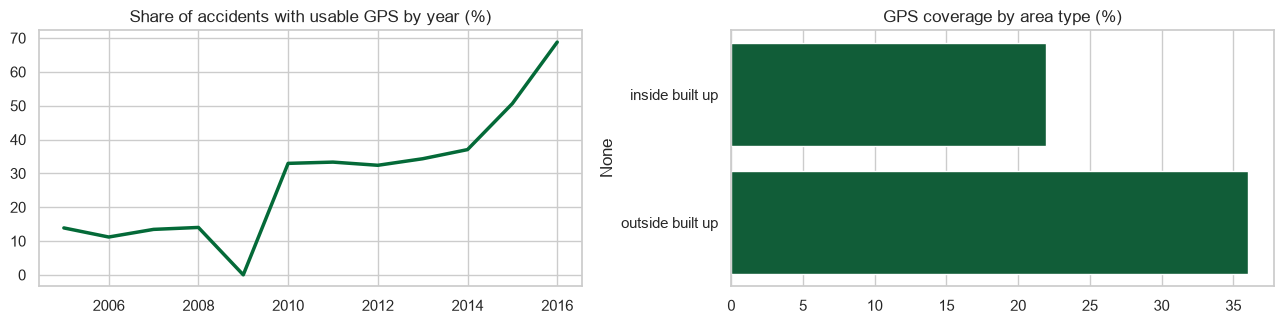

In [ ]:
lon = pd.to_numeric(car.long, errors="coerce")
car["geo_ok"] = car.lat.notna() & (car.lat != 0) & lon.notna() & (lon != 0)
print(f"usable GPS coordinates: {car.geo_ok.sum():,} of {len(car):,} accidents "
      f"({100 * car.geo_ok.mean():.1f}%)")
print(f"lat NaN {car.lat.isna().sum():,} | lat zero {(car.lat == 0).sum():,} | "
      f"long NaN {lon.isna().sum():,} | long zero {(lon == 0).sum():,}")
print("gps flag (M metropole, A Antilles, R Reunion, G Guyane, Y Mayotte):")
print(car.gps.value_counts(dropna=False).head(6).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
car.groupby("year").geo_ok.mean().mul(100).plot(ax=axes[0], color=GREEN, lw=2.5)
axes[0].set_title("Share of accidents with usable GPS by year (%)")
axes[0].set_xlabel("")
cov = pd.Series({"inside built up": 100 * car.loc[car["agg"] == 2, "geo_ok"].mean(),
                 "outside built up": 100 * car.loc[car["agg"] == 1, "geo_ok"].mean()})
sns.barplot(x=cov.values, y=cov.index, color=GREEN, ax=axes[1])
axes[1].set_title("GPS coverage by area type (%)")
plt.tight_layout()
plt.show()

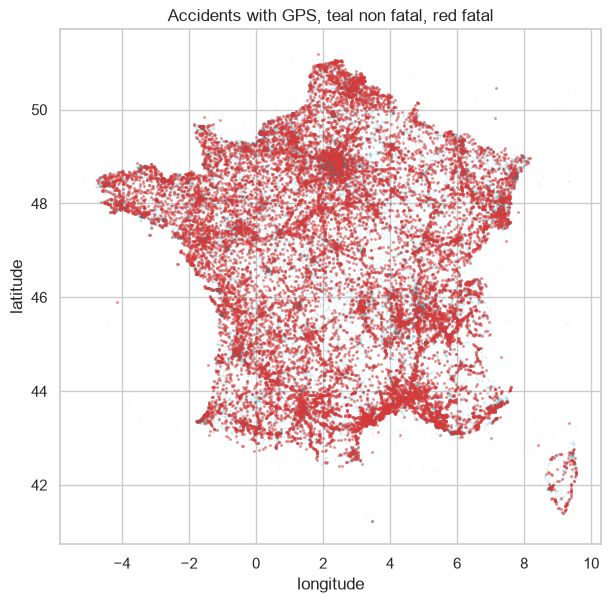

mapped, 120,000 non fatal (sampled) and 19,605 fatal accidents


In [ ]:
# the usable coordinates draw France, stored as degrees x 100000, colored by severity
TEAL, RED = "#0097A9", "#d63a3a"

geo = car[car.geo_ok].copy()
geo["lat_deg"] = geo.lat / 1e5
geo["lon_deg"] = pd.to_numeric(geo.long, errors="coerce") / 1e5
metro = geo[(geo.lat_deg.between(41, 51.5)) & (geo.lon_deg.between(-5.5, 10))].copy()
acc_deaths = usr.groupby("Num_Acc").killed.sum()
metro["fatal"] = metro.Num_Acc.map(acc_deaths).fillna(0) > 0
nonf = metro[~metro.fatal]
nonf = nonf.sample(min(120_000, len(nonf)), random_state=0)
fat = metro[metro.fatal]

plt.figure(figsize=(6.6, 6.2))
plt.scatter(nonf.lon_deg, nonf.lat_deg, s=0.5, alpha=0.05, color=TEAL)
plt.scatter(fat.lon_deg, fat.lat_deg, s=1.6, alpha=0.4, color=RED)
plt.title("Accidents with GPS, teal non fatal, red fatal")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.gca().set_aspect(1.4)
plt.tight_layout()
plt.show()

print(f"mapped, {len(nonf):,} non fatal (sampled) and {len(fat):,} fatal accidents")

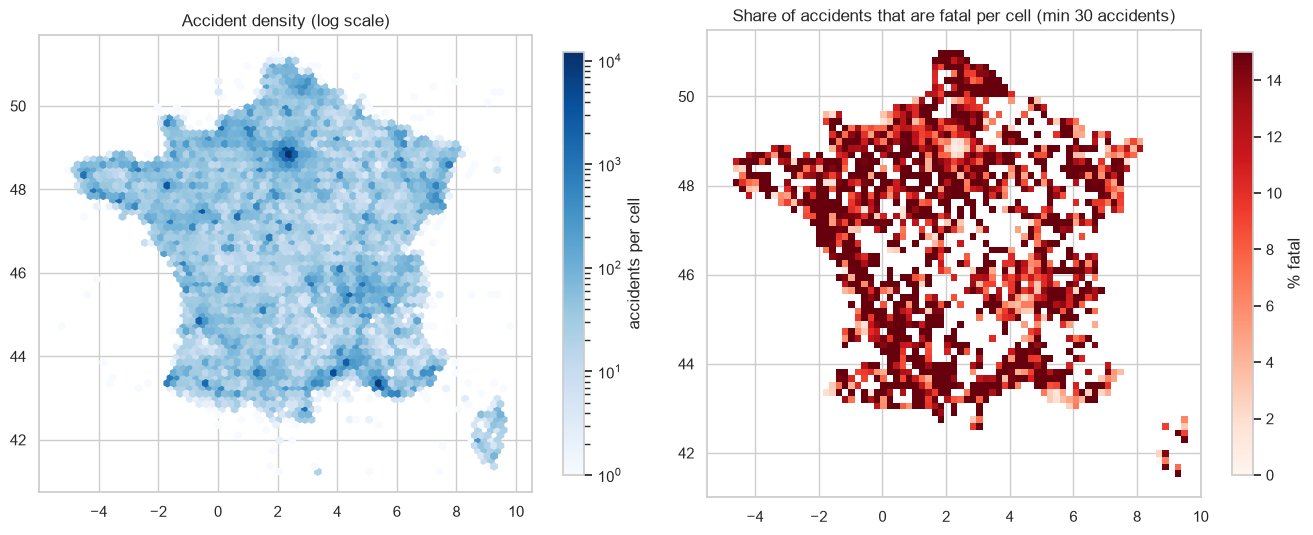

In [ ]:
# distribution of accident locations, where they happen vs where they kill
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6))
hb = axes[0].hexbin(metro.lon_deg, metro.lat_deg, gridsize=70, bins="log", cmap="Blues")
axes[0].set_title("Accident density (log scale)")
axes[0].set_aspect(1.4)
fig.colorbar(hb, ax=axes[0], shrink=0.75, label="accidents per cell")
xe = np.linspace(-5.5, 10, 78)
ye = np.linspace(41, 51.5, 70)
H_all, _, _ = np.histogram2d(metro.lon_deg, metro.lat_deg, bins=[xe, ye])
H_fat, _, _ = np.histogram2d(fat.lon_deg, fat.lat_deg, bins=[xe, ye])
rate = np.where(H_all >= 30, 100 * H_fat / np.maximum(H_all, 1), np.nan)
pc = axes[1].pcolormesh(xe, ye, rate.T, cmap="Reds", vmin=0, vmax=15)
axes[1].set_title("Share of accidents that are fatal per cell (min 30 accidents)")
axes[1].set_aspect(1.4)

fig.colorbar(pc, ax=axes[1], shrink=0.75, label="% fatal")
plt.tight_layout()
plt.show()

C:\Users\User\Documents\vibe\delo\france_accidents\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\User\AppData\Local\Temp\ipykernel_16808\2987830460.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


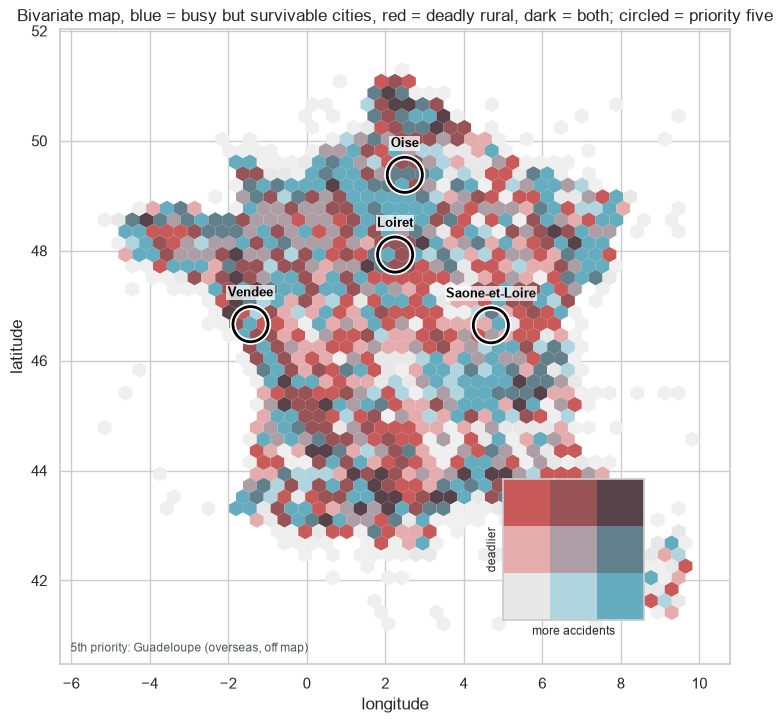

classified 882 hexagons with 30+ accidents | volume terciles (accidents/hex) [ 82 161] | fatality terciles [11.9 16.8]%


In [ ]:
# bivariate hexagon map, both stories in one, accident volume x fatality rate per hex
from matplotlib.colors import to_rgba
# 3x3 palette, rows = fatality (low to high), cols = volume (low to high)
BIV = [["#e8e8e8", "#b0d5df", "#64acbe"],   # low rate:  gray  -> blue  (busy, survivable)
       ["#e4acac", "#ad9ea5", "#627f8c"],   # mid rate
       ["#c85a5a", "#985356", "#574249"]]   # high rate: red   -> dark  (deadly overlap)
EXT = (-5.5, 10, 41, 51.5)
fig, ax = plt.subplots(figsize=(7.8, 7.4))
hb = ax.hexbin(metro.lon_deg, metro.lat_deg, gridsize=44, extent=EXT, mincnt=1)
n = hb.get_array()
hbf = ax.hexbin(metro.lon_deg, metro.lat_deg, C=metro.fatal.astype(int),
                reduce_C_function=np.sum, gridsize=44, extent=EXT, mincnt=1)
d = hbf.get_array()
hbf.remove()
rate = np.divide(d, n, out=np.zeros(len(n)), where=n > 0)
ok = n >= 30   # only classify hexes with enough accidents for a stable rate
vq = np.quantile(np.log10(n[ok]), [1 / 3, 2 / 3])
rq = np.quantile(rate[ok], [1 / 3, 2 / 3])
vcls, rcls = np.digitize(np.log10(n), vq), np.digitize(rate, rq)
faces = [to_rgba(BIV[rcls[i]][vcls[i]]) if ok[i] else to_rgba("#efefef") for i in range(len(n))]
hb.set_array(None)
hb.set_facecolor(faces)
hb.set_edgecolor("none")

# circle the priority five, the départements in the top 25 on both volume and severity
PRIO = {450: "Loiret", 600: "Oise", 710: "Saone-et-Loire", 850: "Vendee"}
cent = metro.groupby("dep")[["lon_deg", "lat_deg"]].median()
for dcode, dname in PRIO.items():
    cx, cy = cent.loc[dcode]
    ax.scatter(cx, cy, s=640, facecolors="none", edgecolors="white", linewidths=4.5, zorder=5)
    ax.scatter(cx, cy, s=640, facecolors="none", edgecolors="black", linewidths=2.0, zorder=6)
    ax.annotate(dname, (cx, cy), textcoords="offset points", xytext=(0, 20), ha="center",
                fontsize=9, fontweight="bold", color="black", zorder=7,
                bbox=dict(fc="white", ec="none", alpha=0.75, pad=1))
ax.text(0.015, 0.02, "5th priority: Guadeloupe (overseas, off map)", transform=ax.transAxes,
        fontsize=8.5, color="#53565A")
ax.set_title("Bivariate map, blue = busy but survivable cities, red = deadly rural, "
             "dark = both; circled = priority five")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_aspect(1.4)
lax = fig.add_axes([0.665, 0.15, 0.19, 0.19])   # 3x3 legend key
lax.imshow([[to_rgba(BIV[r][c]) for c in range(3)] for r in (2, 1, 0)], origin="upper")
lax.set_xticks([])
lax.set_yticks([])
lax.set_xlabel("more accidents", fontsize=8.5)
lax.set_ylabel("deadlier", fontsize=8.5)
plt.tight_layout()
plt.show()


print(f"classified {int(ok.sum()):,} hexagons with 30+ accidents | "
      f"volume terciles (accidents/hex) {np.round(10 ** vq).astype(int)} | "
      f"fatality terciles {np.round(rq * 100, 1)}%")

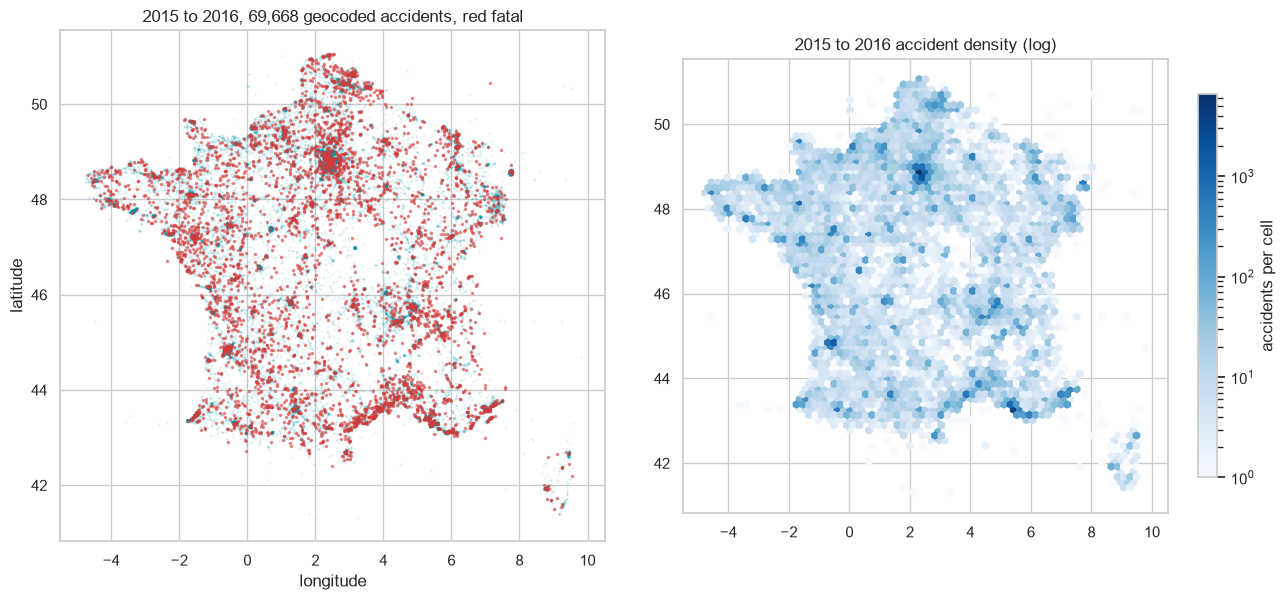

GPS coverage 2015 to 2016: 59.8% of 118,086 accidents


In [ ]:
# 2015 to 2016 only, the best covered years, the least biased map we can draw
recent = metro[metro.year >= 2015]
rn = recent[~recent.fatal]
rf = recent[recent.fatal]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6))
axes[0].scatter(rn.lon_deg, rn.lat_deg, s=0.6, alpha=0.08, color=TEAL)
axes[0].scatter(rf.lon_deg, rf.lat_deg, s=2.2, alpha=0.5, color=RED)
axes[0].set_title(f"2015 to 2016, {len(recent):,} geocoded accidents, red fatal")
axes[0].set_aspect(1.4)
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")
hb = axes[1].hexbin(recent.lon_deg, recent.lat_deg, gridsize=70, bins="log", cmap="Blues")
axes[1].set_title("2015 to 2016 accident density (log)")
axes[1].set_aspect(1.4)


fig.colorbar(hb, ax=axes[1], shrink=0.75, label="accidents per cell")
plt.tight_layout()
plt.show()
print(f"GPS coverage 2015 to 2016: {100 * car.loc[car.year >= 2015, 'geo_ok'].mean():.1f}% "
      f"of {(car.year >= 2015).sum():,} accidents")

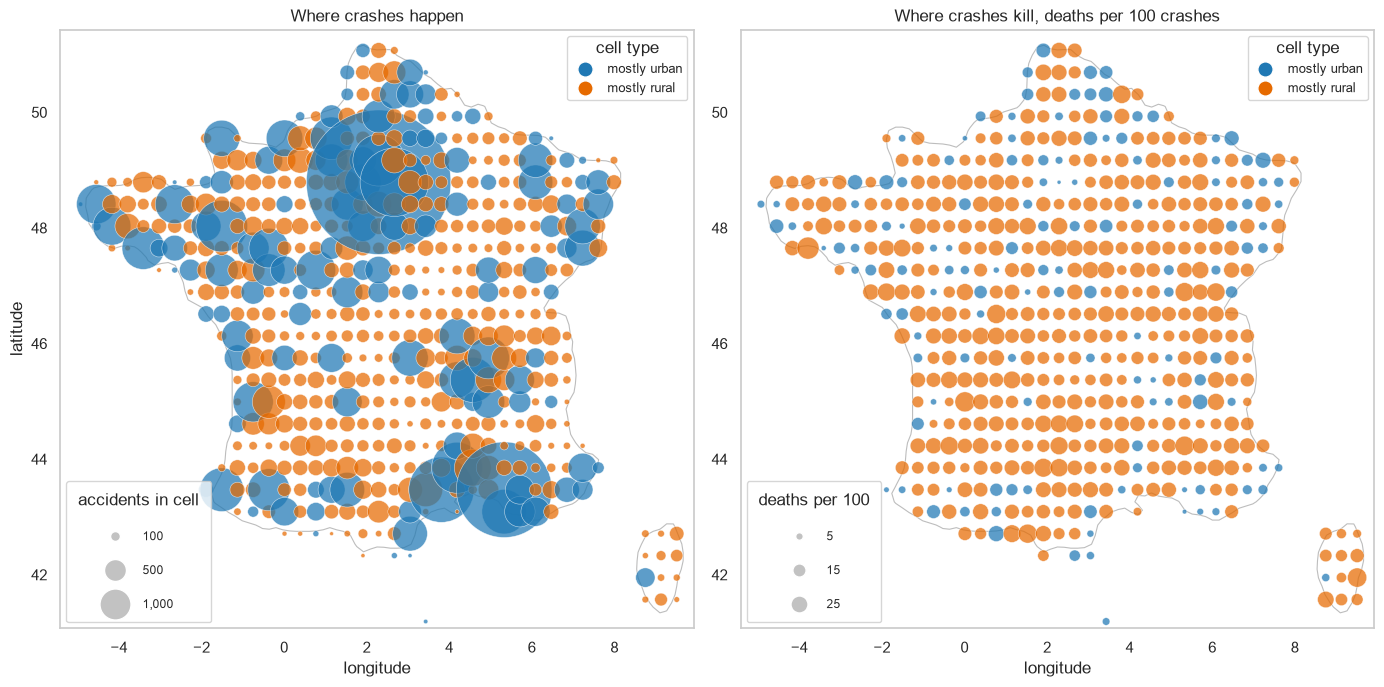

511 cells with 15+ crashes | left sized by accidents, right by deaths per 100 crashes | urban cells 131, rural cells 380


In [ ]:
# side by side, where crashes happen vs where they kill, cells coloured urban or rural
from matplotlib.lines import Line2D
URBAN, RURAL = "#1f78b4", "#e66a00"
EXTM = (-5.5, 10, 41, 51.5)
acc_deaths = usr.groupby("Num_Acc").killed.sum()

# France outline traced from the accident occupancy grid, no shapefile needed
bx, by = np.linspace(EXTM[0], EXTM[1], 96), np.linspace(EXTM[2], EXTM[3], 73)
occ = (np.histogram2d(metro.lon_deg, metro.lat_deg, bins=[bx, by])[0] > 1).astype(float)
for _ in range(2):   # light numpy box blur fills single cell holes and smooths the edge
    occ = (occ + np.roll(occ, 1, 0) + np.roll(occ, -1, 0)
           + np.roll(occ, 1, 1) + np.roll(occ, -1, 1)) / 5
bxc, byc = (bx[:-1] + bx[1:]) / 2, (by[:-1] + by[1:]) / 2

# bin accidents into square cells, count and death rate (deaths per 100 crashes) per cell
step = 0.38
gr = metro.copy()
gr["deaths"] = gr.Num_Acc.map(acc_deaths).fillna(0)
gr["gx"] = np.floor((gr.lon_deg + 5.5) / step)
gr["gy"] = np.floor((gr.lat_deg - 41) / step)
grid = gr.groupby(["gx", "gy"]).agg(n=("agg", "size"), urban=("agg", lambda s: (s == 2).sum()),
                                    deaths=("deaths", "sum")).reset_index()
grid = grid[grid.n >= 15]                        # enough crashes for a stable death rate
grid["cx"] = -5.5 + (grid.gx + 0.5) * step
grid["cy"] = 41 + (grid.gy + 0.5) * step
grid["color"] = np.where(grid.urban >= grid.n / 2, URBAN, RURAL)
grid["dpc"] = 100 * grid.deaths / grid.n

col_h = [Line2D([], [], marker="o", ls="", mfc=URBAN, mec="white", ms=11, label="mostly urban"),
         Line2D([], [], marker="o", ls="", mfc=RURAL, mec="white", ms=11, label="mostly rural")]
panels = [("Where crashes happen", grid.n, 0.5, "accidents in cell", (100, 500, 1000)),
          ("Where crashes kill, deaths per 100 crashes", grid.dpc, 6.0, "deaths per 100", (5, 15, 25))]
fig, axes = plt.subplots(1, 2, figsize=(14, 6.8))
for ax, (title, metric, K, sizelab, sizevals) in zip(axes, panels):
    ax.contour(bxc, byc, occ.T, levels=[0.5], colors="#bdbdbd", linewidths=0.8)
    ax.scatter(grid.cx, grid.cy, s=metric * K, c=grid.color, alpha=0.72,
               edgecolors="white", linewidths=0.4, zorder=3)
    size_h = [Line2D([], [], marker="o", ls="", mfc="#c2c2c2", mec="white",
                     ms=np.sqrt(v * K), label=f"{v:,}") for v in sizevals]
    lg = ax.legend(handles=size_h, loc="lower left", frameon=True, fontsize=8.5,
                   title=sizelab, labelspacing=1.9, borderpad=1.0, handletextpad=1.3)
    ax.add_artist(lg)
    ax.legend(handles=col_h, loc="upper right", frameon=True, fontsize=9, title="cell type")
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_aspect(1.4)
    ax.grid(False)
axes[0].set_ylabel("latitude")
plt.tight_layout()
plt.show()

print(f"{len(grid)} cells with 15+ crashes | left sized by accidents, right by deaths per 100 "
      f"crashes | urban cells {int((grid.color == URBAN).sum())}, "
      f"rural cells {int((grid.color == RURAL).sum())}")

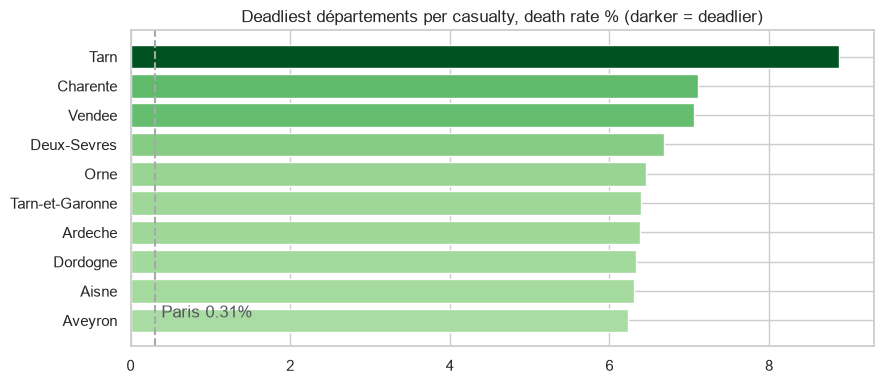

most deaths:          Bouches-du-Rhone (1,679), Herault (1,215), Nord (1,181), Gironde (1,061), Seine-et-Marne (1,039)
deadliest per person: Tarn (8.9%), Charente (7.1%), Vendee (7.1%), Deux-Sevres (6.7%), Orne (6.5%)
overlap between the two top 5 lists: none

top 10 départements hold only 23% of all deaths, the toll is spread across all 87 départements
priority départements, in the top 25 by deaths AND by death rate:
               name  persons  killed  rate
dep                                       
600            Oise    14101     787  5.58
971      Guadeloupe    12297     728  5.92
850          Vendee     9649     681  7.06
450          Loiret    12706     645  5.08
710  Saone-et-Loire    11594     635  5.48


In [ ]:
# the département field is complete for every row, so it carries the geography
DEP_NAMES = {
    1: "Ain", 2: "Aisne", 3: "Allier", 4: "Alpes-de-Haute-Provence", 5: "Hautes-Alpes",
    6: "Alpes-Maritimes", 7: "Ardeche", 8: "Ardennes", 9: "Ariege", 10: "Aube", 11: "Aude",
    12: "Aveyron", 13: "Bouches-du-Rhone", 14: "Calvados", 15: "Cantal", 16: "Charente",
    17: "Charente-Maritime", 18: "Cher", 19: "Correze", 21: "Cote-d'Or", 22: "Cotes-d'Armor",
    23: "Creuse", 24: "Dordogne", 25: "Doubs", 26: "Drome", 27: "Eure", 28: "Eure-et-Loir",
    29: "Finistere", 30: "Gard", 31: "Haute-Garonne", 32: "Gers", 33: "Gironde", 34: "Herault",
    35: "Ille-et-Vilaine", 36: "Indre", 37: "Indre-et-Loire", 38: "Isere", 39: "Jura",
    40: "Landes", 41: "Loir-et-Cher", 42: "Loire", 43: "Haute-Loire", 44: "Loire-Atlantique",
    45: "Loiret", 46: "Lot", 47: "Lot-et-Garonne", 48: "Lozere", 49: "Maine-et-Loire",
    50: "Manche", 51: "Marne", 52: "Haute-Marne", 53: "Mayenne", 54: "Meurthe-et-Moselle",
    55: "Meuse", 56: "Morbihan", 57: "Moselle", 58: "Nievre", 59: "Nord", 60: "Oise",
    61: "Orne", 62: "Pas-de-Calais", 63: "Puy-de-Dome", 64: "Pyrenees-Atlantiques",
    65: "Hautes-Pyrenees", 66: "Pyrenees-Orientales", 67: "Bas-Rhin", 68: "Haut-Rhin",
    69: "Rhone", 70: "Haute-Saone", 71: "Saone-et-Loire", 72: "Sarthe", 73: "Savoie",
    74: "Haute-Savoie", 75: "Paris", 76: "Seine-Maritime", 77: "Seine-et-Marne",
    78: "Yvelines", 79: "Deux-Sevres", 80: "Somme", 81: "Tarn", 82: "Tarn-et-Garonne",
    83: "Var", 84: "Vaucluse", 85: "Vendee", 86: "Vienne", 87: "Haute-Vienne", 88: "Vosges",
    89: "Yonne", 90: "Territoire de Belfort", 91: "Essonne", 92: "Hauts-de-Seine",
    93: "Seine-Saint-Denis", 94: "Val-de-Marne", 95: "Val-d'Oise",
    201: "Corse-du-Sud", 202: "Haute-Corse", 971: "Guadeloupe", 972: "Martinique",
    973: "Guyane", 974: "La Reunion", 976: "Mayotte",
}


def dep_name(code):
    key = code if (code in (201, 202) or code >= 970) else code // 10
    return DEP_NAMES.get(key, f"dep {key}")


depf = u.merge(car[["Num_Acc", "dep"]], on="Num_Acc")
g = depf.groupby("dep").agg(persons=("killed", "size"), killed=("killed", "sum"),
                            rural=("agg", lambda s: (s == 1).mean()))
g = g[g.persons > 5000]
g["rate"] = 100 * g.killed / g.persons
g["name"] = [dep_name(i) for i in g.index]
top = g.sort_values("rate").tail(10)


plt.figure(figsize=(9, 4))
shades = plt.cm.Greens(0.35 + 0.6 * (top.rate - top.rate.min()) / (top.rate.max() - top.rate.min()))
plt.barh(top.name, top.rate, color=shades)
plt.axvline(g.loc[750, "rate"], color=GRAY, lw=1.5, ls="--")
plt.text(g.loc[750, "rate"] + 0.08, 0.1, f"Paris {g.loc[750, 'rate']:.2f}%", color="#53565A")
plt.title("Deadliest départements per casualty, death rate % (darker = deadlier)")
plt.tight_layout()
plt.show()


by_count = g.sort_values("killed", ascending=False).head(5)
by_rate = g.sort_values("rate", ascending=False).head(5)
print("most deaths:          " + ", ".join(f"{r['name']} ({int(r.killed):,})" for _, r in by_count.iterrows()))
print("deadliest per person: " + ", ".join(f"{r['name']} ({r.rate:.1f}%)" for _, r in by_rate.iterrows()))
print("overlap between the two top 5 lists:", set(by_count.index) & set(by_rate.index) or "none")
print()
top10_share = 100 * g.sort_values("killed", ascending=False).head(10).killed.sum() / g.killed.sum()
print(f"top 10 départements hold only {top10_share:.0f}% of all deaths, "
      f"the toll is spread across all {len(g)} départements")


top25_k = set(g.sort_values("killed", ascending=False).head(25).index)
top25_r = set(g.sort_values("rate", ascending=False).head(25).index)
prio = g.loc[sorted(top25_k & top25_r)].sort_values("killed", ascending=False)
print("priority départements, in the top 25 by deaths AND by death rate:")
print(prio[["name", "persons", "killed", "rate"]].round(2).to_string())

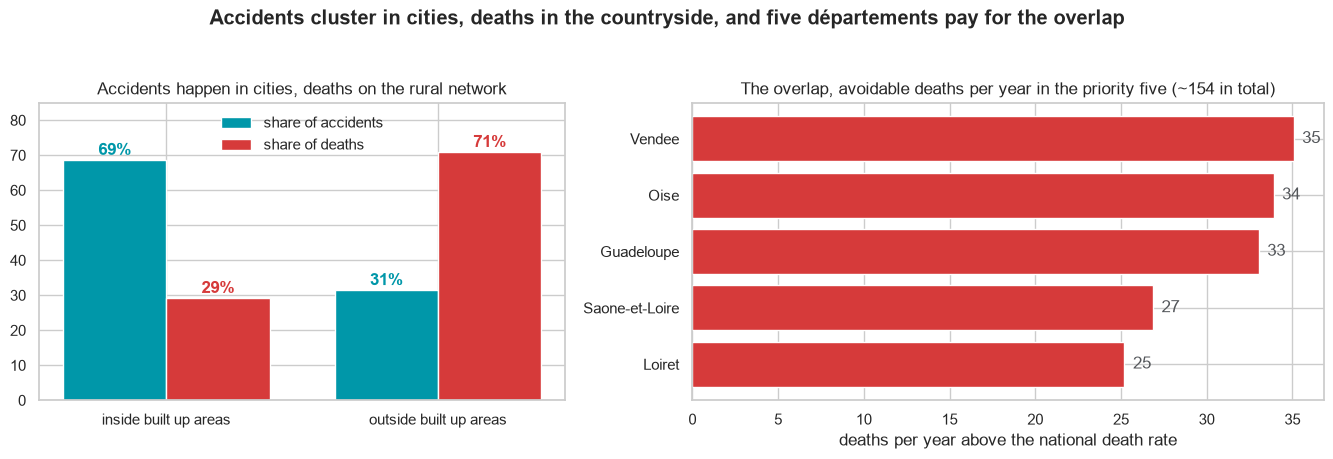

In [ ]:
# the location story in one figure
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), gridspec_kw={"width_ratios": [1, 1.2]})

acc_share = car["agg"].value_counts(normalize=True).mul(100)
death_share = u[u.killed == 1]["agg"].value_counts(normalize=True).mul(100)
x = np.arange(2)
w = 0.38

axes[0].bar(x - w / 2, [acc_share[2], acc_share[1]], w, color=TEAL, label="share of accidents")
axes[0].bar(x + w / 2, [death_share[2], death_share[1]], w, color=RED, label="share of deaths")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["inside built up areas", "outside built up areas"])
for xi, v in zip(x - w / 2, [acc_share[2], acc_share[1]]):
    axes[0].text(xi, v + 1.5, f"{v:.0f}%", ha="center", color=TEAL, fontweight="bold")
for xi, v in zip(x + w / 2, [death_share[2], death_share[1]]):
    axes[0].text(xi, v + 1.5, f"{v:.0f}%", ha="center", color=RED, fontweight="bold")
axes[0].set_title("Accidents happen in cities, deaths on the rural network")
axes[0].legend(frameon=False)
axes[0].set_ylim(0, 85)


nat_rate = 100 * usr.killed.mean()
ex = prio.killed - prio.persons * nat_rate / 100
ey = (ex / 12).sort_values()
axes[1].barh([prio.loc[i, "name"] for i in ey.index], ey.values, color=RED)
for yi, v in enumerate(ey.values):
    axes[1].text(v + 0.5, yi, f"{v:.0f}", va="center", color="#53565A")
axes[1].set_title(f"The overlap, avoidable deaths per year in the priority five "
                  f"(~{ex.sum() / 12:.0f} in total)")

axes[1].set_xlabel("deaths per year above the national death rate")
plt.suptitle("Accidents cluster in cities, deaths in the countryside, "
             "and five départements pay for the overlap", fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

## 7. Takeaways

The inspection surfaced six insight ideas, one per lens:

1. **WHEN**, the road kills most when it is quiet (night hours, Sundays, holidays).
2. **WHO (young)**, young adults are most at risk on weekend nights.
3. **WHO (senior)**, the pedestrian share of deaths is 4x higher for seniors.
4. **WHAT**, deaths dropped for every road user except pedestrians.
5. **WHERE**, the killer road is the ordinary départemental road.
6. **HOW and WHY**, 2 in 3 deaths involve a drifting vehicle or one going straight.

Plus a bonus from the location audit, volume and severity point at different départements (the
top 5 by deaths and the top 5 by death rate share no département) and 3 of 4 crashes cannot be
GPS mapped, both feed the recommendation slide.

These are developed into presentation ready charts in `02_insight_charts.ipynb`.